In [2]:
import pyEDM
import pandas as pd
import numpy as np
import random

p22 = pd.read_csv('../data/processed_22.csv')
p23 = pd.read_csv('../data/processed_23.csv')
p24 = pd.read_csv('../data/processed_24.csv')
p25 = pd.read_csv('../data/processed_25.csv')
combined = pd.concat([p22, p23, p24, p25], ignore_index=True)

Exponentially Weighted Moving

In [3]:
s = combined[["date", "Lpoly_expected_ml"]].copy()
s["date"] = pd.to_datetime(s["date"].astype(str), format="%Y%m%d")
s = s.sort_values("date").set_index("date")

# force daily frequency
s = s.asfreq("D")

ema = s["Lpoly_expected_ml"].ewm(span=30, adjust=False).mean()

s["Lpoly_filled"] = s["Lpoly_expected_ml"]
s.loc[s["Lpoly_filled"].isna(), "Lpoly_filled"] = ema

s["was_imputed"] = s["Lpoly_expected_ml"].isna()

y = s["Lpoly_filled"].values
y_norm = (y - np.mean(y)) / np.std(y)

df = pd.DataFrame({
    "t": np.arange(1, len(y_norm) + 1),        # numeric EDM time
    "x": y_norm
})

In [4]:
N = len(df)
for tp in [1, 3, 7, 14]:
    res = pyEDM.Simplex(
        dataFrame=df,
        lib=f"1 {N}",
        pred=f"1 {N}",
        E=4,
        tau=1,
        Tp=tp,  
        columns="x",
        target="x"
    )

    obs = res["Observations"].to_numpy()
    pred = res["Predictions"].to_numpy()
    mask = np.isfinite(obs) & np.isfinite(pred)

    rho = np.corrcoef(obs[mask], pred[mask])[0, 1]
    print(f"Tp={tp}, rho={rho:.3f}")

Tp=1, rho=0.941
Tp=3, rho=0.952
Tp=7, rho=0.336
Tp=14, rho=0.057


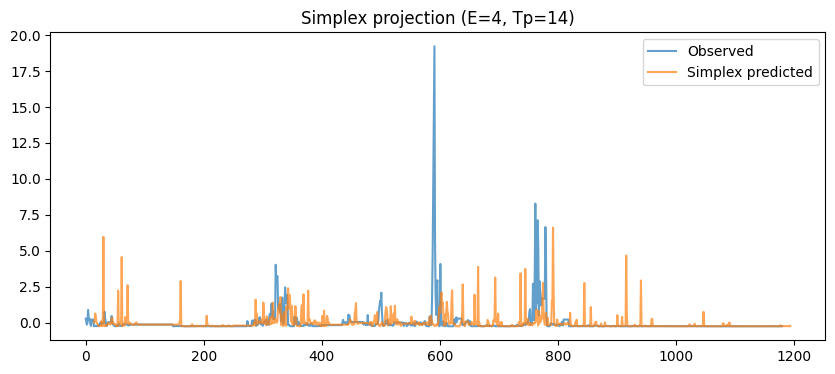

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(obs, label="Observed", alpha=0.7)
plt.plot(pred, label="Simplex predicted", alpha=0.7)
plt.legend()
plt.title("Simplex projection (E=4, Tp=14)")
plt.show()

In [6]:
def random_library_window(N, window=250):
    start = random.randint(1, N - window + 1)
    end = start + window - 1
    return f"{start} {end}"

def simplex_one_bootstrap(df, E=4, Tp=1, window=250):
    N = len(df)

    lib = random_library_window(N, window)
    pred = f"1 {N}"   # predict across whole series

    res = pyEDM.Simplex(
        dataFrame=df,
        lib=lib,
        pred=pred,
        E=E,
        tau=1,
        Tp=Tp,
        columns="x",
        target="x"
    )

    obs = res["Observations"].to_numpy()
    predv = res["Predictions"].to_numpy()

    # remove invalid edge rows
    mask = np.isfinite(obs) & np.isfinite(predv)
    obs = obs[mask]
    predv = predv[mask]

    if len(obs) < 10 or np.std(obs) == 0 or np.std(predv) == 0:
        return np.nan

    return np.corrcoef(obs, predv)[0, 1]

def simplex_bootstrap(df, E=4, Tp=1, B=200, window=250):
    rhos = []

    for b in range(B):
        rho = simplex_one_bootstrap(df, E=E, Tp=Tp, window=window)
        if np.isfinite(rho):
            rhos.append(rho)

    return np.array(rhos)

In [7]:
def effective_rho(x, rhos, Tp):
    acf = abs(pd.Series(x).autocorr(lag=Tp))
    return rhos - acf

x = df["x"].to_numpy()

results = []

for Tp in range(1, 31):
    rhos = simplex_bootstrap(df, E=4, Tp=Tp, B=200, window=250)
    rho_eff = effective_rho(x, rhos, Tp)

    results.append({
        "Tp": Tp,
        "rho_mean": np.mean(rhos),
        "rho_eff_mean": np.mean(rho_eff),
    })

results_df = pd.DataFrame(results)
results_df

,Tp,rho_mean,rho_eff_mean
0,1,0.724124,-0.026711
1,2,0.735598,0.228121
2,3,0.757086,0.393618
3,4,0.508627,0.185067
4,5,0.340947,0.058422
5,6,0.298193,0.098646
6,7,0.257791,0.095613
7,8,0.180706,0.019776
8,9,0.158455,0.009204
9,10,0.143490,-0.031502
